# Lab: Efficient Storage and Serialisation in Python

This lab uses the **NYC TLC Yellow Taxi** trip records as a realistic tabular dataset.

The focus is: "Which format is best for my data?"

Main goals:

- compare text and binary storage
- compare row style and column style thinking
- use `CSV`, `Pickle`, `Parquet`, `Feather`, and NumPy `NPZ`
- inspect Arrow schemas
- measure file size, write time, and read time
- decide which format fits which task

## 1) Setup

For this lab, you may need:

```bash
pip install pandas numpy pyarrow matplotlib
```

If Parquet loading still fails, you can alternatively install:

```bash
pip install fastparquet
```

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

### 1.1) Download and load the dataset

This notebook uses one official monthly Yellow Taxi parquet file from the [NYC TLC data portal](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

We use one monthly parquet file, then keep only a manageable sample for the lab.

You can change the URL to another month later.

In [4]:
DATA_DIR = Path("storage_lab_data")
DATA_DIR.mkdir(exist_ok=True)

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-01.parquet"
parquet_source = DATA_DIR / "yellow_tripdata_2022_01.parquet"

if not parquet_source.exists():
    df_full = pd.read_parquet(url)
    df_full.to_parquet(parquet_source, index=False)
else:
    df_full = pd.read_parquet(parquet_source)

print(f"Full shape: {df_full.shape}")
df_full.head()

Full shape: (2463931, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.80,1.0,N,142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.10,1.0,N,236,42,1,8.0,0.5,0.5,4.00,0.0,0.3,13.30,0.0,0.0
2,2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,N,166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
3,2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,N,114,68,2,8.0,0.5,0.5,0.00,0.0,0.3,11.80,2.5,0.0
4,2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.30,1.0,N,68,163,1,23.5,0.5,0.5,3.00,0.0,0.3,30.30,2.5,0.0


**Notice that the original file to download is in `parquet` format.**

💭 Why do you think this is the case? 🤔

### 1.2) Build a neat working subset

We keep only selected columns and a fixed sample size.
This keeps the lab fast and reproducible.

In [5]:
columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
]

df = df_full[columns].sample(n=100_000, random_state=42).reset_index(drop=True).copy()

# Light cleanup for consistency
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].astype("category")
df["payment_type"] = df["payment_type"].astype("Int64")
df["RatecodeID"] = df["RatecodeID"].astype("Int64")
df["PULocationID"] = df["PULocationID"].astype("Int64")
df["DOLocationID"] = df["DOLocationID"].astype("Int64")

print(df.shape)
df.head()

(100000, 15)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 1.3) Quick `dtype` inspection

Storage format choice becomes much easier when you look at data types first.

In [6]:
df.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                        Int64
store_and_fwd_flag             category
PULocationID                      Int64
DOLocationID                      Int64
payment_type                      Int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
total_amount                    float64
dtype: object

## 2) Exercises

### 2.0) Helper functions for benchmarking

We measure:

- Write time
- Read time
- File size

Implement functions that measure execution time and file size.

You are expected to use these functions for every exercise in this section, and compare the results afterwards.

In [10]:
EXPORT_DIR = DATA_DIR / "exports"
EXPORT_DIR.mkdir(exist_ok=True)

results = {}


def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)


def benchmark(write_func, read_func, path):
    start = time.perf_counter()
    write_func(path)
    write_time = time.perf_counter() - start

    start = time.perf_counter()
    loaded = read_func(path)
    read_time = time.perf_counter() - start

    return loaded, {
        "write_s": write_time,
        "read_s": read_time,
        "size_mb": file_size_mb(path),
    }


def show_results(results_dict):
    return pd.DataFrame(results_dict).T.sort_index().round(4)

### 2.1) NPY and NPZ

Save the `df` in `.npy` and/or `.npz` format 🤔👀

In [11]:
df_numpy = df.copy()

for column in df_numpy.select_dtypes(include=["category"]).columns:
    df_numpy[column] = df_numpy[column].astype(str)

record_array = df_numpy.to_records(index=False)
column_arrays = {
    column: df_numpy[column].to_numpy()
    for column in df_numpy.columns
}

npy_path = EXPORT_DIR / "taxi_subset.npy"
_, npy_metrics = benchmark(
    lambda path: np.save(path, record_array),
    lambda path: np.load(path, allow_pickle=True),
    npy_path,
)
results["NPY"] = npy_metrics

npz_path = EXPORT_DIR / "taxi_subset.npz"
_, npz_metrics = benchmark(
    lambda path: np.savez_compressed(path, **column_arrays),
    lambda path: np.load(path, allow_pickle=True),
    npz_path,
)
results["NPZ"] = npz_metrics

show_results(results)

,write_s,read_s,size_mb
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067


### 2.2) CSV
Save the `df` as `.csv`.

In [12]:
csv_path = EXPORT_DIR / "taxi_subset.csv"
_, csv_metrics = benchmark(
    lambda path: df.to_csv(path, index=False),
    lambda path: pd.read_csv(path),
    csv_path,
)
results["CSV"] = csv_metrics

show_results(results)

,write_s,read_s,size_mb
CSV,0.3812,0.0903,8.4603
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067


### 2.3) Pickle

"Pickle" the `df`.

In [13]:
pickle_path = EXPORT_DIR / "taxi_subset.pkl"
_, pickle_metrics = benchmark(
    lambda path: df.to_pickle(path),
    lambda path: pd.read_pickle(path),
    pickle_path,
)
results["Pickle"] = pickle_metrics

show_results(results)

,write_s,read_s,size_mb
CSV,0.3812,0.0903,8.4603
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067
Pickle,0.0066,0.0059,11.1604


### 2.4) Parquet
Save the `df` as `.parquet`.

In [15]:
parquet_path = EXPORT_DIR / "taxi_subset.parquet"
_, parquet_metrics = benchmark(
    lambda path: df.to_parquet(path, index=False),
    lambda path: pd.read_parquet(path),
    parquet_path,
)
results["Parquet"] = parquet_metrics
show_results(results)

,write_s,read_s,size_mb
CSV,0.3812,0.0903,8.4603
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067
Parquet,0.0806,0.0061,2.6922
Pickle,0.0066,0.0059,11.1604


### 2.5) Feather
Save the `df` as `.feather`.


In [16]:
father_path = EXPORT_DIR / "taxi_subset.feather"
_, feather_metrics = benchmark(
    lambda path: df.to_feather(path),
    lambda path: pd.read_feather(path),
    father_path,
)
results["Feather"] = feather_metrics
show_results(results)

,write_s,read_s,size_mb
CSV,0.3812,0.0903,8.4603
Feather,0.3234,0.0068,3.8396
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067
Parquet,0.0806,0.0061,2.6922
Pickle,0.0066,0.0059,11.1604


### 2.6) Compare results

Compare all the data you gathered above and plot the results.

,write_s,read_s,size_mb
CSV,0.3812,0.0903,8.4603
Feather,0.3234,0.0068,3.8396
NPY,0.1864,0.2601,12.4386
NPZ,0.2542,0.0018,2.1067
Parquet,0.0806,0.0061,2.6922
Pickle,0.0066,0.0059,11.1604


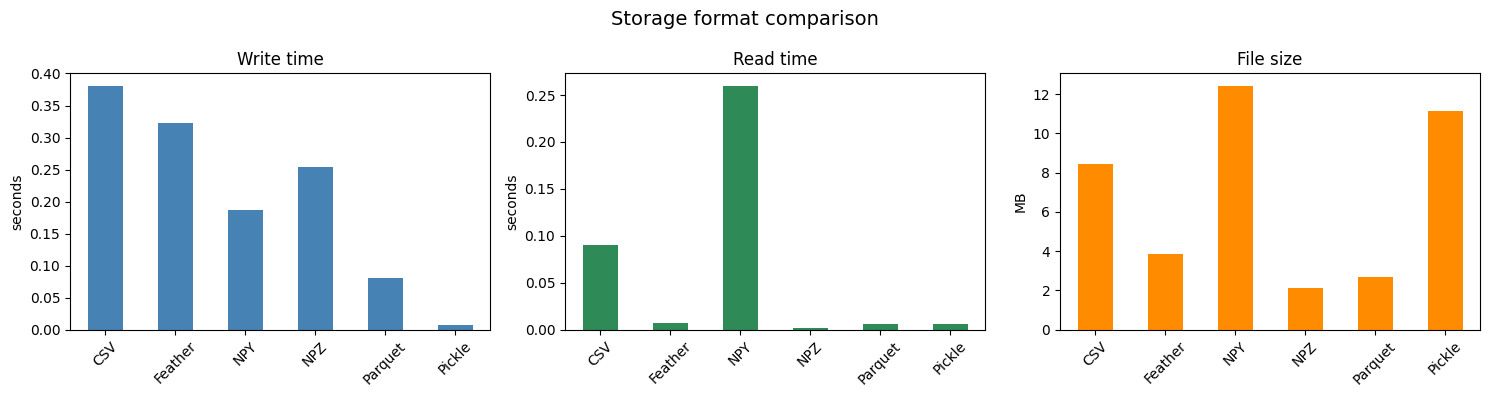

In [18]:
import matplotlib.pyplot as plt

summary_df = show_results(results)
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

summary_df["write_s"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Write time")
axes[0].set_ylabel("seconds")
axes[0].tick_params(axis="x", rotation=45)

summary_df["read_s"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Read time")
axes[1].set_ylabel("seconds")
axes[1].tick_params(axis="x", rotation=45)

summary_df["size_mb"].plot(kind="bar", ax=axes[2], color="darkorange")
axes[2].set_title("File size")
axes[2].set_ylabel("MB")
axes[2].tick_params(axis="x", rotation=45)

fig.suptitle("Storage format comparison", fontsize=14)
fig.tight_layout()
plt.show()

### 2.7) Optional extension

Try one of these:

- compare `np.save` with `np.savez_compressed`
- test another sample size
- test another month of NYC taxi data
- add memory profiling with `df.memory_usage(deep=True)`

## 3) Observation and Discussion

### 3.1) Check dtype preservation

Formats differ in how well they preserve structure and types. Check the data type of the data you saved.

In [19]:
original_dtypes = df.dtypes.astype(str)

loaded_frames = {
    "CSV": pd.read_csv(csv_path),
    "Pickle": pd.read_pickle(pickle_path),
    "Parquet": pd.read_parquet(parquet_path),
    "Feather": pd.read_feather(EXPORT_DIR / "taxi_subset.feather"),
    "NPY": pd.DataFrame(np.load(npy_path, allow_pickle=True)),
}

with np.load(npz_path, allow_pickle=True) as npz_data:
    loaded_frames["NPZ"] = pd.DataFrame({name: npz_data[name] for name in npz_data.files})

comparison = pd.DataFrame({"Original": original_dtypes})
for format_name, loaded_df in loaded_frames.items():
    comparison[format_name] = loaded_df.dtypes.astype(str)

match_summary = pd.DataFrame(
    {
        "dtype_match_count": {
            name: (loaded_df.dtypes.astype(str) == original_dtypes).sum()
            for name, loaded_df in loaded_frames.items()
        },
        "all_match": {
            name: (loaded_df.dtypes.astype(str) == original_dtypes).all()
            for name, loaded_df in loaded_frames.items()
        },
    }
).sort_index()

print("Dtype match summary:")
display(match_summary)

print("Detailed dtype comparison:")
display(comparison)

Dtype match summary:


,dtype_match_count,all_match
CSV,8,False
Feather,15,True
NPY,10,False
NPZ,10,False
Parquet,15,True
Pickle,15,True


Detailed dtype comparison:


,Original,CSV,Pickle,Parquet,Feather,NPY,NPZ
tpep_pickup_datetime,datetime64[us],str,datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us]
tpep_dropoff_datetime,datetime64[us],str,datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us]
passenger_count,float64,float64,float64,float64,float64,float64,float64
trip_distance,float64,float64,float64,float64,float64,float64,float64
RatecodeID,Int64,float64,Int64,Int64,Int64,float64,float64
store_and_fwd_flag,category,str,category,category,category,str,str
PULocationID,Int64,int64,Int64,Int64,Int64,int64,int64
DOLocationID,Int64,int64,Int64,Int64,Int64,int64,int64
payment_type,Int64,int64,Int64,Int64,Int64,int64,int64
fare_amount,float64,float64,float64,float64,float64,float64,float64


### 3.2) Parquet column selection demo

`Parquet` is especially well suited to columnar storage and column wise reading. Read a few columns from your saved Parquet data while tracking the read time.

In [20]:
selected_columns = [
    "tpep_pickup_datetime",
    "trip_distance",
    "total_amount",
]

start = time.perf_counter()
full_parquet_again = pd.read_parquet(parquet_path)
full_read_time = time.perf_counter() - start

start = time.perf_counter()
selected_parquet = pd.read_parquet(parquet_path, columns=selected_columns)
selected_read_time = time.perf_counter() - start

column_demo = pd.DataFrame(
    {
        "read_s": [full_read_time, selected_read_time],
        "columns_loaded": [full_parquet_again.shape[1], selected_parquet.shape[1]],
    },
    index=["Full parquet", "Selected columns"],
).round(4)

display(column_demo)
selected_parquet.head()

,read_s,columns_loaded
Full parquet,0.0171,15
Selected columns,0.0025,3


,tpep_pickup_datetime,trip_distance,total_amount
0,2022-01-15 00:22:49,1.50,14.16
1,2022-01-13 17:50:32,2.60,16.30
2,2022-01-19 18:41:39,3.73,21.36
3,2022-01-08 10:35:44,5.96,24.96
4,2022-01-26 20:08:13,0.69,8.80


### 3.3) Take-home lessons

Fill in this section based on your observations and understanding of the topic.

### Suggested conclusions

- Parquet and Feather give a strong balance of speed, small file size, and dtype preservation.
- Pickle is very fast inside Python, but it is less portable and produces larger files.
- CSV is easy to share, but it is slower and often loses type information.
- NPZ is compact for NumPy-style data, but it is less convenient for mixed tabular datasets.
- For analytical workflows, Parquet is usually the best default choice.